# EQB Inc. / PC Financial Acquisition - Risk Analysis
### ALY6130 Risk Management for Analytics | Group 2
** Md Maniur Rahman | Rahul Reddy Basani | Shanmugapriya G**



---


### Problem Statement

EQB Inc. (parent of EQ Bank) announced in December 2025 its acquisition of PC Financial - the banking arm of Loblaw Companies Limited - in a deal that would transfer approximately 3.5 million customers and a credit card portfolio to EQB's platform. As a Schedule I bank-adjacent transaction requiring OSFI and Ministerial approval, the deal presents a complex risk landscape spanning cybersecurity, regulatory compliance, customer attrition, data privacy, credit quality, and strategic execution.

This notebook provides a risk assessment of the EQB/PC Financial acquisition, identifying, scoring, classifying, and visualizing 40 risks - including three positive risks (opportunities) - using the course scoring scale (Likelihood × Impact) and a Random Forest classifier. The analysis is conducted ex-ante, as a forward-looking assessment from the point of deal announcement.


In [1]:
%matplotlib inline

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')


Libraries loaded successfully.


In [13]:
# Load risk register from Excel file
# Place risk_register_EQB.xlsx in the same folder as this notebook
df_risk_register = pd.read_excel('ALY6130_risk_register_EQB_Assignmnet3_Group2.xlsx')

# Preview the first few rows
df_risk_register.head()


,Risk #,Date,The Risk of/That,Caused by,Resulting In,Consequence/Impact,Likelihood Score,Impact Score,Risk Score,"Priority (H, M, L)",Mitigation,Risk Owner,Open/Closed
0,R-01,2025-12-16,Cybersecurity breach during IT system integration,Merging EQB and PC Financial banking platforms...,Unauthorized access to 3.5M+ customer financia...,"Regulatory fines, breach remediation costs, cu...",9,9,81,H,Implement zero-trust architecture; conduct pre...,Chief Information Security Officer (CISO),Open
1,R-02,2025-12-16,Regulatory approval delay by OSFI / Minister o...,Complex deal requiring Schedule I bank-linked ...,"Delayed deal close beyond 2026 target, prolong...","Integration cost escalation, reputational unce...",3,8,24,M,Proactive engagement with OSFI and Minister of...,Chief Legal Officer / Regulatory Affairs,Open
2,R-03,2025-12-16,Customer attrition from PC Financial portfolio...,PC Financial customers unfamiliar with EQB bra...,"Deposit outflow and reduced portfolio size, un...","Revenue shortfall, reduced cross-sell base, an...",7,8,56,H,Launch early customer communication campaign; ...,Chief Marketing Officer / Customer Experience,Open
3,R-04,2025-12-16,Data migration failure or corruption of custom...,Transfer of 3.5M+ customer records and loan fi...,"Data loss, transaction errors, service outages...","Operational disruption, customer harm, potenti...",3,9,27,M,Conduct parallel-run testing; establish rollba...,Chief Technology Officer / Integration PMO,Open
4,R-05,2025-12-16,Key talent loss PC Financial staff exit durin...,"Uncertainty about role redundancy, compensatio...","Loss of institutional knowledge, operational g...","Integration delays, elevated HR costs, and red...",9,4,36,M,Implement retention bonuses for critical roles...,Chief People Officer / HR Integration Lead,Open


In [14]:
# Select and rename relevant columns
risk_df = df_risk_register[['Risk #', 'The Risk of/That', 'Likelihood Score', 'Impact Score']].dropna()
risk_df.columns = ['Risk_ID', 'Risk_Description', 'Likelihood_Score', 'Impact_Score']

# Compute Risk Score (Likelihood × Impact) using course scoring scale
risk_df['Risk_Score'] = risk_df['Likelihood_Score'] * risk_df['Impact_Score']

# Define severity label based on course thresholds
# High >= 45 | Medium 21-44 | Low <= 20
def classify_severity(row):
    if row['Risk_Score'] >= 45:
        return 'High'
    elif row['Risk_Score'] >= 21:
        return 'Medium'
    else:
        return 'Low'

# Apply function to classify severity
risk_df['Severity_Label'] = risk_df.apply(classify_severity, axis=1)

# Flag positive risks (opportunities)
risk_df['Risk_Type'] = risk_df['Risk_ID'].apply(
    lambda x: 'Opportunity' if x in ['R-38', 'R-39', 'R-40'] else 'Threat'
)

# View cleaned data
risk_df.head(10)


,Risk_ID,Risk_Description,Likelihood_Score,Impact_Score,Risk_Score,Severity_Label,Risk_Type
0,R-01,Cybersecurity breach during IT system integration,9,9,81,High,Threat
1,R-02,Regulatory approval delay by OSFI / Minister o...,3,8,24,Medium,Threat
2,R-03,Customer attrition from PC Financial portfolio...,7,8,56,High,Threat
3,R-04,Data migration failure or corruption of custom...,3,9,27,Medium,Threat
4,R-05,Key talent loss PC Financial staff exit durin...,9,4,36,Medium,Threat
5,R-06,Brand confusion / reputational damage during P...,7,6,42,Medium,Threat
6,R-07,Integration cost overrun beyond the $105M budget,7,6,42,Medium,Threat
7,R-08,Loblaw co-dependency disruption operational c...,5,8,40,Medium,Threat
8,R-09,Cross-sell conversion failure EQB fails to up...,5,8,40,Medium,Threat
9,R-10,Interest rate sensitivity affecting mortgage p...,5,8,40,Medium,Threat


### Exploratory Data Analysis


In [5]:
# Summary statistics
print('=== Risk Score Summary ===')
print(risk_df[['Likelihood_Score', 'Impact_Score', 'Risk_Score']].describe().round(2))
print()
print('=== Severity Distribution ===')
print(risk_df['Severity_Label'].value_counts())


=== Risk Score Summary ===
       Likelihood_Score  Impact_Score  Risk_Score
count             40.00         40.00       40.00
mean               5.20          6.70       34.50
std                2.07          1.57       16.38
min                3.00          4.00       12.00
25%                3.00          6.00       24.00
50%                5.00          6.00       30.00
75%                7.00          8.00       42.00
max                9.00          9.00       81.00

=== Severity Distribution ===
Severity_Label
Medium    24
Low        9
High       7
Name: count, dtype: int64


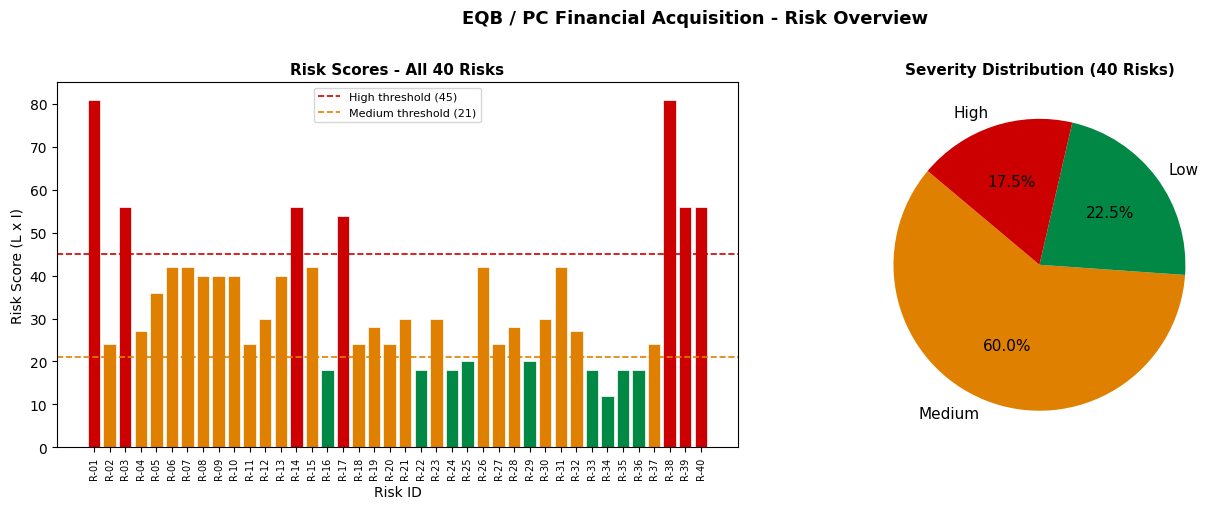

In [6]:
# Risk Score Distribution by Severity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = risk_df['Severity_Label'].map({'High': '#CC0000', 'Medium': '#E08000', 'Low': '#008844'})
axes[0].bar(risk_df['Risk_ID'], risk_df['Risk_Score'], color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(y=45, color='#CC0000', linestyle='--', linewidth=1.2, label='High threshold (45)')
axes[0].axhline(y=21, color='#E08000', linestyle='--', linewidth=1.2, label='Medium threshold (21)')
axes[0].set_xlabel('Risk ID', fontsize=10)
axes[0].set_ylabel('Risk Score (L x I)', fontsize=10)
axes[0].set_title('Risk Scores - All 40 Risks', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].legend(fontsize=8)

counts = risk_df['Severity_Label'].value_counts()
pie_colors = [{'High':'#CC0000','Medium':'#E08000','Low':'#008844'}[l] for l in counts.index]
axes[1].pie(counts.values, labels=counts.index, colors=pie_colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize':11})
axes[1].set_title('Severity Distribution (40 Risks)', fontsize=11, fontweight='bold')

plt.suptitle('EQB / PC Financial Acquisition - Risk Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Random Forest Classifier

A Random Forest classifier with 100 decision trees is trained to predict risk severity (Low / Medium / High) based on Likelihood and Impact scores. Because the dataset is small (40 observations), 5-fold cross-validation is used instead of a single train-test split to produce more reliable accuracy estimates.


In [7]:
from sklearn.ensemble import RandomForestClassifier

# This model uses a Random Forest classifier with 100 decision trees to predict risk
# severity levels based on likelihood and impact scores.
# Define the model
model = RandomForestClassifier(n_estimators=100, random_state=42)


In [8]:
# Re-select features and target: defines the feature matrix (X) using Likelihood and Impact scores,
# and create the target variable (y) by assigning severity labels (Low, Medium, High) based on
# a rule-based thresholding logic applied to each risk.
X = risk_df[['Likelihood_Score', 'Impact_Score']]
y = risk_df.apply(
    lambda row: 'High' if row['Risk_Score'] >= 45
    else 'Medium' if row['Risk_Score'] >= 21
    else 'Low',
    axis=1
)


In [9]:
from sklearn.model_selection import cross_val_score

# Evaluate the Random Forest model using 5-fold cross-validation, which is preferred over
# a single train-test split due to the small size of the dataset.
# Report the mean accuracy across folds and individual fold scores to assess how well
# the model generalizes to unseen risk classification scenarios.
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'Mean accuracy (5-fold CV): {scores.mean():.2f}')
print('Accuracy for each fold:', scores)


Mean accuracy (5-fold CV): 0.93
Accuracy for each fold: [1.    0.875 0.75  1.    1.   ]


### Note:
Despite the high accuracy, this result should be interpreted with caution due to class imbalance and the small dataset size. Adding more labeled data or using stratified sampling techniques would improve model evaluation reliability.


In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=5)

# Classification metrics
print('Classification Report:')
print(classification_report(y, y_pred_cv))

# Confusion Matrix
print('Confusion Matrix:')
print(confusion_matrix(y, y_pred_cv))


Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.86      0.92         7
         Low       1.00      0.78      0.88         9
      Medium       0.89      1.00      0.94        24

    accuracy                           0.93        40
   macro avg       0.96      0.88      0.91        40
weighted avg       0.93      0.93      0.92        40

Confusion Matrix:
[[ 6  0  1]
 [ 0  7  2]
 [ 0  0 24]]


The model performs well on the majority class (Medium) but struggles with minority classes (Low and High) due to class imbalance.

Recommendation: Having a balanced and larger dataset for fair and accurate classification across all classes.


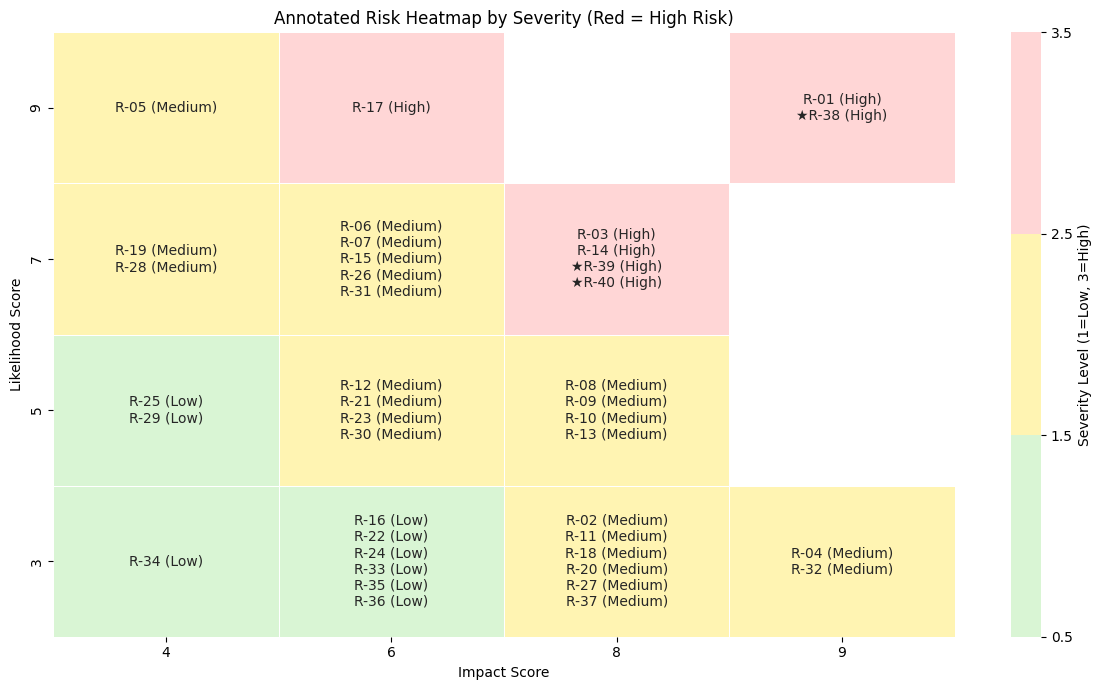

In [11]:
# Copy the original DataFrame
severity_map = risk_df.copy()

# Define severity classification logic
def classify_severity(row):
    if row['Risk_Score'] >= 45:
        return 'High'
    elif row['Risk_Score'] >= 21:
        return 'Medium'
    else:
        return 'Low'

# Apply classification and map severity to numeric scale
severity_map['Severity'] = severity_map.apply(classify_severity, axis=1)
severity_levels = {'Low': 1, 'Medium': 2, 'High': 3}
severity_map['Severity_Num'] = severity_map['Severity'].map(severity_levels)

# Create Risk ID label (positive risks get star prefix)
POSITIVE_IDS = {'R-38', 'R-39', 'R-40'}
severity_map['Label'] = severity_map.apply(
    lambda row: ('\u2605' if row['Risk_ID'] in POSITIVE_IDS else '') +
                row['Risk_ID'] + ' (' + row['Severity'] + ')',
    axis=1
)

# Pivot table with most severe risk per cell
pivot_severity = severity_map.groupby(
    ['Likelihood_Score', 'Impact_Score'])['Severity_Num'].max().unstack()
pivot_severity = pivot_severity.sort_index(ascending=False)
pivot_severity = pivot_severity[pivot_severity.columns.sort_values()]

# Annotation matrix (Risk IDs and severity)
label_matrix = severity_map.groupby(
    ['Likelihood_Score', 'Impact_Score'])['Label'] \
    .apply(lambda x: '\n'.join(x)).unstack(fill_value='')
label_matrix = label_matrix.sort_index(ascending=False)
label_matrix = label_matrix[label_matrix.columns.sort_values()]

# Discrete colormap: green=Low, yellow=Medium, red=High
cmap = ListedColormap(['#d9f5d4', '#fff4b2', '#ffd6d6'])
bounds = [0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

# Plot severity heatmap with annotations
plt.figure(figsize=(12, 7))
sns.heatmap(pivot_severity, annot=label_matrix, fmt='', cmap=cmap, norm=norm,
            linewidths=0.5, cbar_kws={'label': 'Severity Level (1=Low, 3=High)'})
plt.title('Annotated Risk Heatmap by Severity (Red = High Risk)')
plt.xlabel('Impact Score')
plt.ylabel('Likelihood Score')
plt.tight_layout()
plt.show()


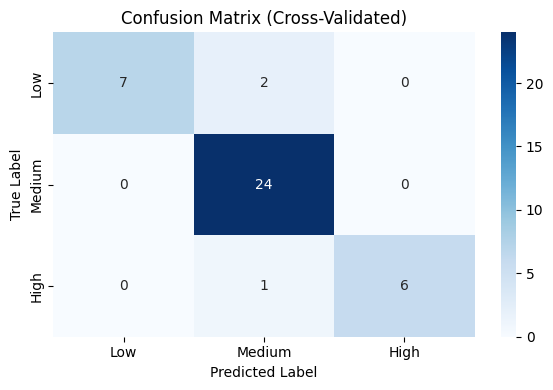

In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

# Reuse model and labels
y_pred_cv = cross_val_predict(model, X, y, cv=5)
conf_matrix = confusion_matrix(y, y_pred_cv, labels=['Low', 'Medium', 'High'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix (Cross-Validated)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


### Interpretation
We are using a Random Forest classifier to predict one of three severity categories: Low, Medium and High.

### Confusion Matrix Breakdown

**24 out of 24 Medium risks were correctly predicted:** Very strong performance here.

**6 out of 7 High risks were correctly predicted:** 1 High risk was misclassified as Medium.

**7 out of 9 Low risks were correctly predicted:** 2 Low risks were misclassified as Medium.

The model achieves **93% overall accuracy** (5-fold cross-validation). Medium risks dominate the dataset (24/40), which explains the strong performance on that class. Low and High classes are smaller, making occasional misclassification more likely at class boundaries.

**Recommendation:**Stratified sampling to be used for class imbalance hanling
